# iso codes

In [14]:
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    
    # 2. Hard constraint: Only look for languages explicitly mentioned in Title/Abstract
    detected_languages = []
    false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        alpha3 = lang.part3
        if not name or not alpha3:
            continue
        # Avoid short matching like 'it' or 'no' by matching full words and require name length >=4
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({alpha3})")  # Full language name with code

    # Example output
    print(f"Title: {title}")
    print(f"Detected languages: {detected_languages}")


Title: ATLAS: Agentic or Latent Visual Reasoning? One Word is Enough for Both
Detected languages: []
Title: FutureSim: Replaying World Events to Evaluate Adaptive Agents
Detected languages: []
Title: Is Grep All You Need? How Agent Harnesses Reshape Agentic Search
Detected languages: ['Even (eve)']
Title: MetaBackdoor: Exploiting Positional Encoding as a Backdoor Attack Surface in LLMs
Detected languages: ['Even (eve)']
Title: Text Knows What, Tables Know When: Clinical Timeline Reconstruction via Retrieval-Augmented Multimodal Alignment
Detected languages: []
Title: MeMo: Memory as a Model
Detected languages: []
Title: Self-Distilled Agentic Reinforcement Learning
Detected languages: []
Title: Forgetting That Sticks: Quantization-Permanent Unlearning via Circuit Attribution
Detected languages: []
Title: MemEye: A Visual-Centric Evaluation Framework for Multimodal Agent Memory
Detected languages: []
Title: Talk is (Not) Cheap: A Taxonomy and Benchmark Coverage Audit for LLM Attacks
Det

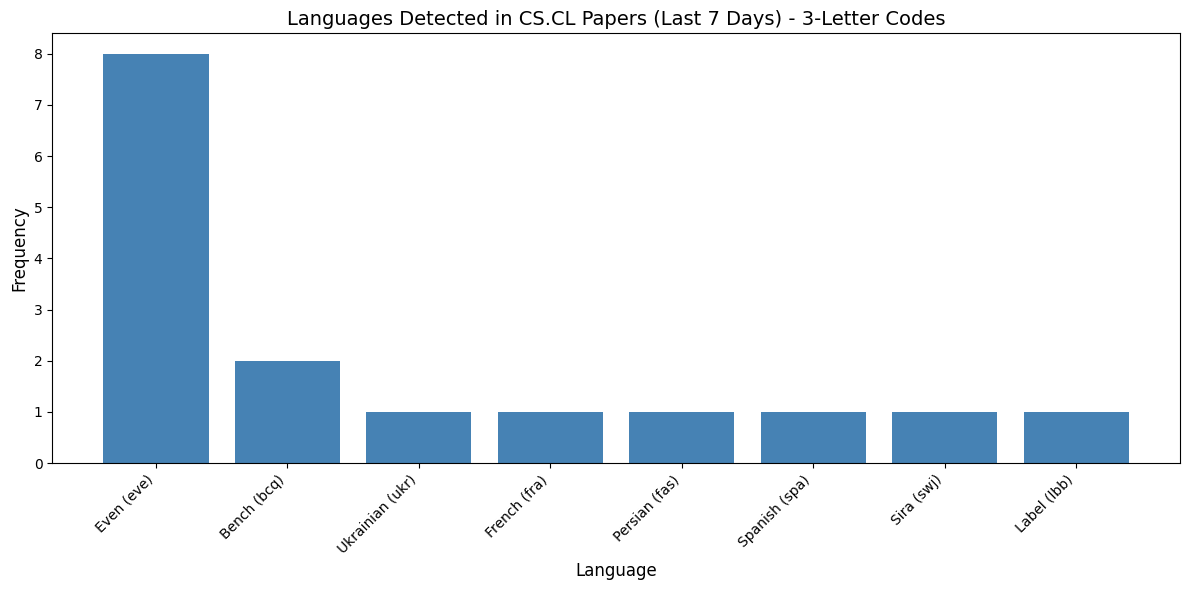

Total papers analyzed: 50
Total language mentions detected: 16
Unique languages detected: 8


In [15]:
import matplotlib.pyplot as plt
from collections import Counter
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

# Collect all detected languages (with codes)
all_detected_languages = []
false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    detected_languages = []
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        alpha3 = lang.part3
        if not name or not alpha3:
            continue
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({alpha3})")
    
    all_detected_languages.extend(detected_languages)

# Count language occurrences
language_counter = Counter(all_detected_languages)

if language_counter:
    # Get top 10 most detected languages
    top_languages = language_counter.most_common(10)
    display_names, counts = zip(*top_languages)
    
    # Create bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(display_names)), counts, color='steelblue')
    plt.xticks(range(len(display_names)), display_names, rotation=45, ha='right')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Languages Detected in CS.CL Papers (Last 7 Days) - 3-Letter Codes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Total papers analyzed: {len(list(client.results(search)))}")
    print(f"Total language mentions detected: {len(all_detected_languages)}")
    print(f"Unique languages detected: {len(language_counter)}")
else:
    print("No languages detected in papers from the last 7 days.")


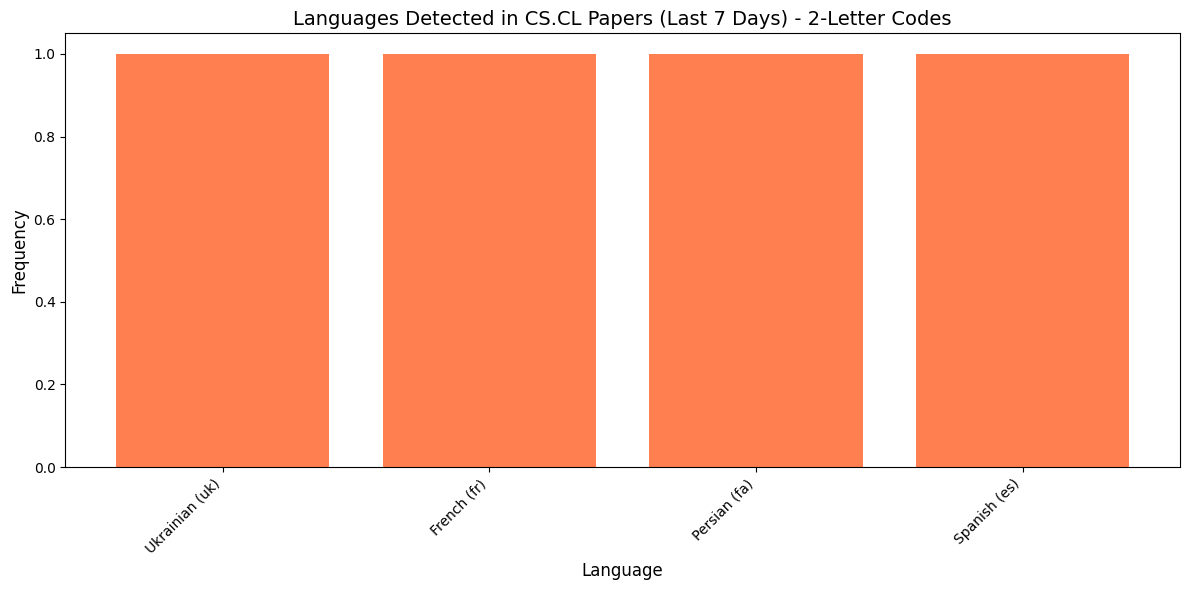

Total papers analyzed: 50
Total language mentions detected: 4
Unique languages detected: 4


In [16]:
import matplotlib.pyplot as plt
from collections import Counter
import arxiv
import re
from iso639.language import ALL_LANGUAGES
from datetime import datetime, timedelta

# Construct the default API client.
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
search = arxiv.Search(query=query, max_results=50, sort_by=arxiv.SortCriterion.SubmittedDate)

# Collect all detected languages using 2-letter codes (ISO 639-1)
all_detected_languages_2letter = []
false_positives = {"English", "Modern", "Program", "The", "Are", "Day"}

results = client.results(search)
for result in results:
    abstract = result.summary
    title = result.title
    detected_languages = []
    
    for lang in ALL_LANGUAGES:
        name = lang.name
        part1 = lang.part1  # 2-letter code
        if not name or not part1:
            continue
        if len(name) < 4:
            continue
        pattern = r"\b" + re.escape(name) + r"\b"
        if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
            if name not in false_positives:
                detected_languages.append(f"{name} ({part1})")
    
    all_detected_languages_2letter.extend(detected_languages)

# Count language occurrences
language_counter_2letter = Counter(all_detected_languages_2letter)

if language_counter_2letter:
    # Get top 10 most detected languages
    top_languages_2letter = language_counter_2letter.most_common(10)
    display_names_2letter, counts_2letter = zip(*top_languages_2letter)
    
    # Create bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(display_names_2letter)), counts_2letter, color='coral')
    plt.xticks(range(len(display_names_2letter)), display_names_2letter, rotation=45, ha='right')
    plt.xlabel('Language', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Languages Detected in CS.CL Papers (Last 7 Days) - 2-Letter Codes', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Total papers analyzed: {len(list(client.results(search)))}")
    print(f"Total language mentions detected: {len(all_detected_languages_2letter)}")
    print(f"Unique languages detected: {len(language_counter_2letter)}")
else:
    print("No languages detected in papers from the last 7 days.")


# from some language code repo (lang filter)

In [ ]:
import arxiv
import re
from datetime import datetime, timedelta
import time
import json, os

In [ ]:


# Define languages to ignore (from categorize_filtered_papers.ipynb)
languages_to_ignore = "Apache,Laura,Fang,Mono,Ma,Maria,Sam,Bench,Zhuang,Male,Nara,So,Hu,Kim,Label,The,To,Yong,The,To,Adele,Are,Foma,Kaur,Bau,Kato,Dek,Naman,Dom,As,The,To,As,Dan,E,The,To,U,Even,En,Chung,Dong,Shi,Tai,Thompson,Gao,Ir,Pan,Ali,Rao,Han,Doe,Titan,Ha,Sa,Tu,Lau,Siri,Wan,She,Dai,Ding,Kang,Ge,Koch,Che,Mann,Zou,Pei,Yao,Lou,Sydney,Ju,Sha,Day,Miwa,Bai,Ko,Ga,Pal,Pe,Gun,Hung,Con,Cun,Serrano,Sui,Bu,Mehri,Od,Haji,Gal,Gey,Lui,Ho,Furu,Ak,Kao,Aro,Gen,Moro,Notre,Ido,Ron,Were,Bai,Sahu,Dem,Melo,Rama,Hunde,Dii,Yala,Sauri".split(',')
languages_to_ignore = languages_to_ignore + "Uni,One,Yi,Na,Bit,Pa".split(',') + ["are", "as", "e", "en", "even", "one", "so", "to", "apache", "au", "u", "bit", "she", "siri", "day", "gun", "label", "notre"]
languages_to_ignore = set(languages_to_ignore)

# Load lang_classes from categorize_filtered_papers.ipynb
lang_classes = {}
base_path = "/Users/akw/Downloads/Some-Languages-are-More-Equal-than-Others-33d9e115809150c07f4e55816e9b57e64505a13e/Language_List/Language_Classes_According_To/DataSet_Availability"

for i in range(6):
    file_path = f"{base_path}/{i}.txt"
    try:
        with open(file_path, "r", encoding="utf-8") as fp:
            lang_classes[i] = set(fp.read().strip().split("\n"))
            print(f"✓ Loaded class {i}: {len(lang_classes[i])} languages")
    except FileNotFoundError:
        print(f"✗ Could not find file for class {i}: {file_path}")

# Flatten all languages from all classes
all_tracked_languages = set()
for class_id, langs in lang_classes.items():
    all_tracked_languages.update(langs)

# Remove ignored languages
all_tracked_languages = all_tracked_languages - languages_to_ignore

print(f"\nLoaded {len(all_tracked_languages)} tracked languages from {len(lang_classes)} classes (after filtering)")
print(f"Sample languages: {list(all_tracked_languages)[:15]}")


✓ Loaded class 0: 6134 languages
✓ Loaded class 1: 130 languages
✓ Loaded class 2: 96 languages
✓ Loaded class 3: 30 languages
✓ Loaded class 4: 22 languages
✓ Loaded class 5: 7 languages

Loaded 6322 tracked languages from 6 classes (after filtering)
Sample languages: ['Ambulas', 'Usoi', 'Aushiri', 'Borna', 'Zayein', 'Yankunytjatjara', 'Pankararú', 'Aeka', 'Warrgamay', 'Chuj', 'Wasco-Wishram', 'Zumbun', 'Réunion French Creole', 'Aché', 'Buduma']
✗ Error retrieving papers from arXiv: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=cat%3Acs.CL+AND+submittedDate%3A%5B202605132238+TO+202605202238%5D&id_list=&sortBy=submittedDate&sortOrder=descending&start=0&max_results=100)


In [ ]:
# Construct the default API client with delay
client = arxiv.Client()

# Calculate date range for last 7 days
end_date = datetime.now()
start_date = end_date - timedelta(days=7)

# Format dates for arXiv API (YYYYMMDDHHMM)
start_date_str = start_date.strftime("%Y%m%d%H%M")
end_date_str = end_date.strftime("%Y%m%d%H%M")

# Build query with category and date filter
# query = f"cat:cs.CL AND submittedDate:[{start_date_str} TO {end_date_str}]"
query = f"cat:cs.CL"
search = arxiv.Search(query=query, max_results=10, sort_by=arxiv.SortCriterion.SubmittedDate)
try:
    results = client.results(search)
    # save results to a list to avoid multiple API calls
    results_list = list(results)
    print(f"✓ Successfully retrieved {len(results_list)} papers from arXiv")
    # save to jsonl
    os.makedirs("../data/raw", exist_ok=True)
    with open("../data/raw/arxiv_papers_last_7_days.jsonl", "w", encoding="utf-8") as fp:
        for result in results_list:
            paper_data = {
                "id": result.entry_id,
                "title": result.title,
                "abstract": result.summary,
                "authors": [author.name for author in result.authors],
                "published": result.published.isoformat(),
                "updated": result.updated.isoformat(),
                "categories": result.categories,
                "pdf_url": result.pdf_url
            }
            fp.write(json.dumps(paper_data) + "\n")
except Exception as e:
    print(f"✗ Error retrieving papers from arXiv: {e}")
    results_list = []

✓ Successfully retrieved 10 papers from arXiv


In [24]:
results_list 

[{'id': 'http://arxiv.org/abs/2605.20179v1',
  'title': 'TIDE: Efficient and Lossless MoE Diffusion LLM Inference with I/O-aware Expert Offload',
  'abstract': 'Diffusion Large Language Models (dLLMs) have emerged as a competitive alternative to autoregressive (AR) models, offering better hardware utilization and bidirectional context through parallel block-level decoding. However, as dLLMs continue to scale up with mixture-of-experts (MoE) architectures, their deployment on resource-constrained devices remains an open challenge. Existing AR-based methods often incur either prohibitive I/O overhead or significant compute bottlenecks. In this work, we propose TIDE, a novel resource-efficient inference system that leverages the temporal stability of expert activations during the diffusion process within the block. Specifically, we leverage the temporal stability of expert activations during the diffusion process within the block and introduce an interval-based expert refresh strategy tha

In [26]:
with open("../data/raw/arxiv_papers_last_7_days.jsonl", "r", encoding="utf-8") as fp:
    results_list = [json.loads(line) for line in fp]
# Track papers with tracked languages
papers_with_tracked_langs = []
try:
    result_count = 0
    for result in results_list:
        result_count += 1
        abstract = result["abstract"]
        title = result["title"]
        detected_langs = []
        
        # Check for tracked languages
        for lang in all_tracked_languages:
            if not lang or len(lang) < 2:
                continue
            # Case-insensitive word boundary matching
            pattern = r"\b" + re.escape(lang) + r"\b"
            if re.search(pattern, abstract, re.IGNORECASE) or re.search(pattern, title, re.IGNORECASE):
                if lang not in languages_to_ignore:  # Double check
                    detected_langs.append(lang)
        
        if detected_langs:
            papers_with_tracked_langs.append({
                'title': title,
                'url': result.entry_id,
                'languages': detected_langs
            })
            print(f"\n✓ FLAGGED (Paper {result_count}) - Title: {title[:80]}...")
            print(f"  Languages: {detected_langs}")
        
        # Add delay to avoid rate limiting
        time.sleep(2)
    
    print(f"\n\n=== SUMMARY ===")
    print(f"Total papers analyzed: {result_count}")
    print(f"Papers with tracked languages: {len(papers_with_tracked_langs)}")
except Exception as e:
    print(f"Error during arXiv query: {e}")
    print("Note: arXiv API may have rate-limited the request. Try again later.")




=== SUMMARY ===
Total papers analyzed: 10
Papers with tracked languages: 0
